In [5]:
# Solutions of Linear Equations:

import numpy as np

# Create the array modeling the voltages:
A = np.array ([[2, 1, 4, 1 ],
            [3, 4, -1, -1 ],
            [1, -4, 1, 5 ],
            [2, -2, 1, 3 ]], float)

# create solution vector:
v = np.array([-4,3,9,7],float)

# Now make a length instead of hardcoding for the loops
N = len(v)

# Want a for loop to diivide leading entry of row, to get 1 on diagonal:

# solve answer with np, use to check for loop answer, this uses LU decomp:
x = np.linalg.solve(A,v)
print(x)



    


[ 2. -1. -2.  1.]


In [11]:
# solve with Gauss elim traditional:

# DIVIDE BY DIAGONAL ELEMENT
for m in range(N):

    # find the diagonal element
    div = A[m,m]
    A[m,:] /= div
    v[m] /= div

    # now subtract this element, need m+1 to move to next row, and stop at 4, only 3 times: 
    for l in range(m+1,N):
        mult = A[l,m]
        A[l,:] -= mult*A[m,:]
        v[l] -= mult*v[m]

print(A)
print(v)
        



[[ 1.          0.5         2.          0.5       ]
 [ 0.          1.         -4.         -4.        ]
 [-0.         -0.          1.          0.23333333]
 [-0.         -0.         -0.          1.        ]]
[-9.6        -6.6        -2.9         5.92015209]


In [12]:
# Gauss Elim Example

from numpy import array, empty

# Make the matrix you want to solve:
A = array ([[2, 1, 4, 1 ],
            [3, 4, -1, -1 ],
            [1, -4, 1, 5 ],
            [2, -2, 1, 3 ]], float)

# create the vector: 
v = array([-4,3,9,7],float)
# choose N to be the length of V, in our example it is 4
N = len(v)

# Gauss Elim: 
# start with a loop to divide by leading m in A and v:
for m in range(N):
    div = A[m,m]
    A[m,:] /= div
    v[m] /= div

    # now subtract this from lower rows to zero the lead:
    for i in range(m+1,N):
        mult = A[i,m]
        A[i,:] -= mult*A[m,:]
        v[i] -= mult*v[m]

# backsub to solve:
x = empty(N,float)
for m in range(N-1,-1,-1):
    x[m] = v[m]
    for i in range(m+1,N):
        x[m] -= A[m,i]*x[i]

print(x)

[ 2. -1. -2.  1.]


In [43]:
# Relaxation method nonlinear equations:
import matplotlib.pyplot as plt

def f(x,c=2):
    return 1-np.exp(-c*x)

def relx_method(xg=1, eps=10**-15, max_steps=100):
    
    for i in range(max_steps):
        xg1 = f(xg)
        if abs(xg1 - xg) < eps:
            print(xg1)
            break
        
        xg = xg1 
        
    else:
            print("Does not converge")


    
print(xg)
    

0.7968121300200213


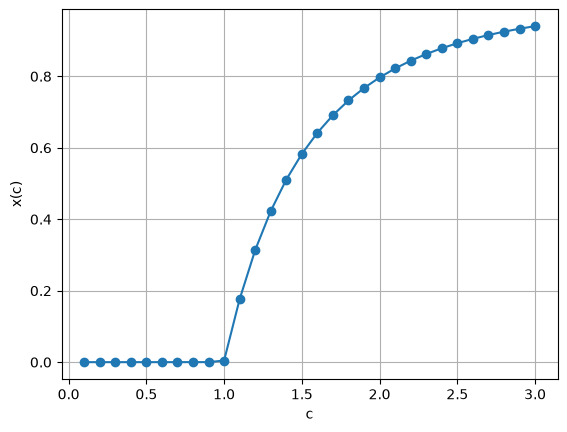

In [62]:
import numpy as np
import matplotlib.pyplot as plt

# define the function we want to solve, note it is not solveable analytically
def f(x, c=2):
    return 1 - np.exp(-c * x)

# create a function that implements the relaxtion method
def rel_meth(func, xg=1.0, eps=1e-5, max_steps=1000): # define parameters (func, guess, error, steps of loop)
    for _ in range(max_steps):# create a for loop to iterate a solution
        xg1 = func(xg)# start with guess and then put into iterative function, save as new x guess
        if abs(xg1-xg) < eps:# if in the for loop to see if x is converging to a fixed point up to some error
             return xg1 # if so return that x, that is solution
        xg = xg1 # if not update xg to the new calculated xg1, and then start the loop again
    raise RuntimeError("Did not converge")# catch error to not let machine keep running

# create a function that gets the arrays
def get_arrays():
    c_array = np.arange(0.1,3.1,0.1) # create array  from 0.1 to 3.0 by 0.1
    x_array = np.zeros(len(c_array)) # create a zero array same length as above to later put answer in
    
    for i in range(len(c_array)): # create a loop the length of the array, that uses the lambda method to solve one rel method per item in the array
        x_array[i] = rel_meth(lambda x: f(x,c_array[i]))
    return c_array, x_array
 

# create a simple plot of the gathered data:
def plot_simply(c_data, x_data): # define a plot function that takes two data sets
    plt.plot(c_data, x_data, 'o-') # we plot c values on horizontal and x(c) on the vertical, data, the o gives dots on actual points
    plt.xlabel("c")
    plt.ylabel("x(c)")
    plt.grid()
    plt.show()



def main():
    c_vals, x_vals = get_arrays()
    plot_simply(c_vals, x_vals)

if __name__ == "__main__":
    main()
